In [1]:
import pandas as pd
import numpy as np
import uncertainties as un
import uncertainties.unumpy as unp
import matplotlib.pyplot as plt

from uncertainties.unumpy import nominal_values as noms
from uncertainties.unumpy import std_devs as stds

idx = pd.IndexSlice

In [14]:
def escatter(x, y, ax=None, **kwargs):
    """"
    Function for making a scatter plot with uncertainties.unumpy.uarray data.
    
    Parameters
    ----------
    x : uncerainty.unumpy.uarray or numpy.ndarray
    y : uncerainty.unumpy.uarray or numpy.ndarray
    ax : matplotlib.axes.Axes
    kwargs
        passed to plt.scatter
    
    Returns
    -------
    matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(1,1)
    if isinstance(x, pd.core.frame.DataFrame):
        x = x.values.flatten()
    if isinstance(y, pd.core.frame.DataFrame):
        y = y.values.flatten()
        
    if 'c' in kwargs:
        ma = ax.scatter(unp.nominal_values(x), unp.nominal_values(y), **kwargs)
    else:
        ma = None
        ax.scatter(unp.nominal_values(x), unp.nominal_values(y), **kwargs)
    
    ax.errorbar(unp.nominal_values(x), unp.nominal_values(y),
                xerr=unp.std_devs(x), 
                yerr=unp.std_devs(y),
                lw=0, elinewidth=1, color=(0,0,0,0.4), zorder=-1)
    
    return ax, ma

## Load Data

In [15]:
experiments = ['Mg', 'Sr', 'Mg+Sr', 'B',]

In [16]:
dat = pd.read_csv('Data/data_vaterite_26052022_python.csv', header=[0,1,2,3], index_col=0)
dat.sort_index(1, inplace=True)
dat.head()

/tmp/ipykernel_907173/1656903317.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.sort_index will be keyword-only.
  dat.sort_index(1, inplace=True)


Type       metadata            precipitate                                     \
Quantity      Batch Experiment        B/Ca    Mg/Ca    Na/Ca    Sr/Ca    d13C   
Instrument       NA         NA        iCap     iCap     iCap     iCap GS-IRMS   
Unit             NA         NA    mmol/mol mmol/mol mmol/mol mmol/mol  permil   
15                1    Control         NaN  -0.0224  26.0077   0.0271  108.01   
16                1         Mg         NaN   0.8879  11.3045   0.0290  116.33   
17                1         Mg         NaN   1.7272  11.1567   0.0294  114.12   
18                1         Mg         NaN   3.8458   8.2277   0.0318  121.50   
19                1         Mg         NaN   6.6334   8.6663   0.0330  136.93   

Type                                                     seed  ...  \
Quantity   diameter percent_vaterite                     B/Ca  ...   
Instrument      SEM              XRD Agilent (10) / iCap (28)  ...   
Unit             μm          percent                 mmol/mol  ...   
15             5.57            79.47                   0.0168  ...   
16             5.60            80.31                   0.0168  ...   
17             5.59            80.99                   0.0168  ...   
18             5.39            79.71                   0.0168  ...   
19             5.19            79.71                   0.0168  ...   

Type       solution_end                             solution_start  \
Quantity             Sr    d13C              pH_NBS              B   
Instrument      Agilent GS-IRMS           electrode        Agilent   
Unit               mmol  permil Unnamed: 30_level_3           mmol   
15             0.000966   -2.00               7.461       0.010101   
16             0.000941   -2.43               7.486       0.045179   
17             0.000846   -3.12               7.479      -0.003059   
18             0.000846   -4.12               7.523       0.030233   
19             0.000764   -4.28               7.579       0.012196   

Type                                                             \
Quantity             C         Ca        Mg        Na        Sr   
Instrument dissolution    Agilent   Agilent   Agilent   Agilent   
Unit              mmol       mmol      mmol      mmol      mmol   
15                   5  12.845237 -0.001428  0.247976  0.001013   
16                   5  12.208096  1.026357  0.224830  0.000964   
17                   5  10.702777  2.068886  0.233039  0.000869   
18                   5  10.712261  4.928338  0.223382  0.000888   
19                   5  11.587594  9.428138  0.213820  0.001118   

Type                            
Quantity                pH_NBS  
Instrument           electrode  
Unit       Unnamed: 29_level_3  
15                       8.213  
16                       8.209  
17                       8.193  
18                       8.200  
19                       8.198  

[5 rows x 30 columns]

### Deal with uncertainties

In [17]:
composition_Fstd = 0.05  # 5% on compositions

isotope_std = 1.  # 1 permil on isotops
xrd_std = 0.02  # 2% on xrd

In [18]:
dat.columns.levels[2]

Index(['Agilent', 'Agilent (10) / iCap (28)', 'GS-IRMS', 'NA', 'SEM', 'XRD',
       'dissolution', 'electrode', 'iCap'],
      dtype='object', name='Instrument')

In [19]:
ind = idx[:,:,['iCap', 'Agilent', 'Agilent (10) / iCap (28)'],:]
dat.loc[:,ind] = unp.uarray(
    nominal_values=dat.loc[:,ind].values,
    std_devs=abs(dat.loc[:,ind].values) * composition_Fstd
)

ind = idx[:,:,'GS-IRMS',:]
dat.loc[:,ind] = unp.uarray(
    nominal_values=dat.loc[:,ind].values,
    std_devs=isotope_std
)

ind = idx[:,:,'XRD',:]
dat.loc[:,ind] = unp.uarray(
    nominal_values=dat.loc[:,ind].values,
    std_devs=xrd_std
)

/usr/lib/python3.10/site-packages/numpy/lib/function_base.py:2387: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)


### Calculate solution ratios

In [20]:
for el in ['Mg', 'Na', 'Sr']:
    dat[('solution_start', f'{el}/Ca', 'calc', 'mol/mol')] = dat[('solution_start', f'{el}')].values / dat[('solution_start', 'Ca')].values
    dat[('solution_end', f'{el}/Ca', 'calc', 'mol/mol')] = dat[('solution_end', f'{el}')].values / dat[('solution_end', 'Ca')].values
    
dat[('solution_start', 'B/C', 'calc', 'mol/mol')] = dat[('solution_start', 'B')].values / dat[('solution_start', 'C')].values

/tmp/ipykernel_907173/4265382713.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('solution_end', f'{el}/Ca', 'calc', 'mol/mol')] = dat[('solution_end', f'{el}')].values / dat[('solution_end', 'Ca')].values
/tmp/ipykernel_907173/4265382713.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('solution_start', f'{el}/Ca', 'calc', 'mol/mol')] = dat[('solution_start', f'{el}')].values / dat[('solution_start', 'Ca')].values
/tmp/ipykernel_907173/4265382713.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('solution_start', 'B/C', 'calc', 'mol/mol')] = dat[('solution_start', 'B')].values / dat[('solution_start', 'C')].values


### 1. Calculate the fractional abundance of overgrowth in the experiment

$$
\begin{align}
f &= \frac{M_{OG}}{M_{OG} + M{seed}} \\
\delta^{13}C_{PPT} &= \delta^{13}C_{seed} (1 - f) + \delta^{13}C_{OG} f \\
\delta^{13}C_{PPT} &= \delta^{13}C_{seed} - f (\delta^{13}C_{seed} - \delta^{13}C_{OG}) \\
f &= \frac{\delta^{13}C_{seed} - \delta^{13}C_{PPT}}{\delta^{13}C_{seed} - \delta^{13}C_{OG}}
\end{align}
$$

In [21]:
d13C_OG_mean = noms(dat.loc[(dat.metadata == 1).values, ('solution_end', 'd13C')]).mean().item()
d13C_OG_std = noms(dat.loc[(dat.metadata == 1).values, ('solution_end', 'd13C')]).std().item()

d13C_OG = un.ufloat(d13C_OG_mean, d13C_OG_std)

/tmp/ipykernel_907173/3392522324.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  d13C_OG_mean = noms(dat.loc[(dat.metadata == 1).values, ('solution_end', 'd13C')]).mean().item()
/tmp/ipykernel_907173/3392522324.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  d13C_OG_std = noms(dat.loc[(dat.metadata == 1).values, ('solution_end', 'd13C')]).std().item()


In [22]:
dat[('derived', 'f', 'calc', 'fractional_abundance')] = (dat.loc[:, ('seed','d13C')] - dat.loc[:, ('precipitate','d13C')]) / (dat.loc[:, ('seed','d13C')] - d13C_OG)

/tmp/ipykernel_907173/1772920265.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('derived', 'f', 'calc', 'fractional_abundance')] = (dat.loc[:, ('seed','d13C')] - dat.loc[:, ('precipitate','d13C')]) / (dat.loc[:, ('seed','d13C')] - d13C_OG)


In [23]:
dat.derived.f.head()

Instrument,calc
Unit,fractional_abundance
15,0.435+/-0.006
16,0.393+/-0.006
17,0.404+/-0.006
18,0.366+/-0.006
19,0.288+/-0.006


### 2. Calculate Overgrowth composition

$$
\begin{align}
X/Ca_{PPT} &= X/Ca_{seed} (1 - f)  + X/Ca_{OG} f \\
X/Ca_{OG} &= \frac{X/Ca_{PPT} - X/Ca_{seed}(1 - f)}{f}  \\
\end{align}
$$

In [24]:
dat[('seed', 'B/Ca')] = 0  # this has not been measured yet

ratios = ['Mg/Ca', 'Sr/Ca', 'Na/Ca', 'B/Ca']

for rat in ratios:
    dat[('overgrowth', rat, 'calc', 'mol/mol')] = 1e-3 * (dat[('precipitate', rat)].values - (1 - dat.derived.f.values) * dat[('seed', rat)].values) / dat.derived.f.values
    # # replace any values below zero with zeros
    # ind = dat[('overgrowth', rat, 'calc', 'mol/mol')] < 0
    # dat.loc[ind, ('overgrowth', rat, 'calc', 'mol/mol')] = 0

/tmp/ipykernel_907173/602020607.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('seed', 'B/Ca')] = 0  # this has not been measured yet
/tmp/ipykernel_907173/602020607.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('overgrowth', rat, 'calc', 'mol/mol')] = 1e-3 * (dat[('precipitate', rat)].values - (1 - dat.derived.f.values) * dat[('seed', rat)].values) / dat.derived.f.values
/tmp/ipykernel_907173/602020607.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('overgrowth', rat, 'calc', 'mol/mol')] = 1e-3 * (dat[('precipitate', rat)].values - (1 - dat.derived.f.values) * dat[('seed', rat)].values) / dat.derived.f.values


/tmp/ipykernel_907173/126602885.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  escatter(x=dat.loc[ind, ('solution_start', exp)], y=dat.loc[ind, ('overgrowth', 'Na/Ca')], ax=ax)
/tmp/ipykernel_907173/126602885.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  escatter(x=dat.loc[ind, ('solution_start', 'Mg')], y=dat.loc[ind, ('overgrowth', 'Na/Ca')], ax=ax)


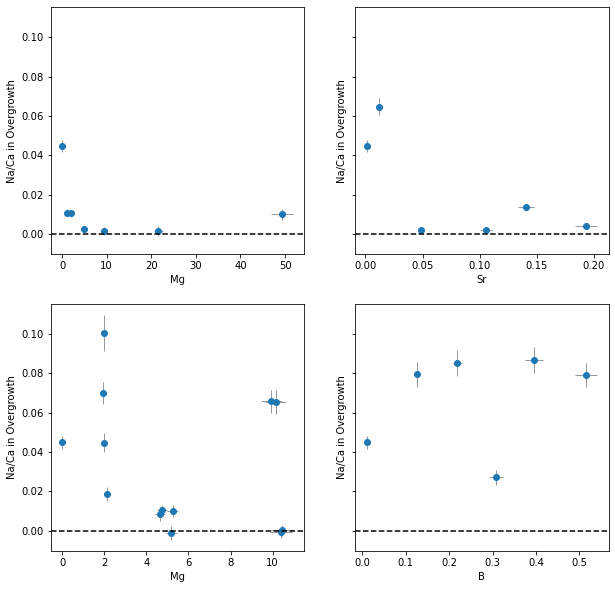

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
for exp, ax in zip(experiments, axs.flat):
    ind = ((dat.metadata.Experiment == exp).values | (dat.metadata.Experiment == 'Control').values)

    if exp != 'Mg+Sr':
        escatter(x=dat.loc[ind, ('solution_start', exp)], y=dat.loc[ind, ('overgrowth', 'Na/Ca')], ax=ax)
        ax.set_xlabel(exp)
    else:
        escatter(x=dat.loc[ind, ('solution_start', 'Mg')], y=dat.loc[ind, ('overgrowth', 'Na/Ca')], ax=ax)
        ax.set_xlabel('Mg')
    ax.set_ylabel('Na/Ca in Overgrowth')
    ax.axhline(0, ls='--', color='k')

#### Calculation overgrowth partitioning 

In [26]:
for el in ['Mg', 'Na', 'Sr']:
    dat[('overgrowth', f'D_{el}', 'calc', None)] = dat[('overgrowth', f'{el}/Ca')].values / dat[('solution_start', f'{el}/Ca')].values

dat[('overgrowth', f'D_B', 'calc', None)] = dat[('overgrowth', 'B/Ca')].values / dat[('solution_start', f'B/C')].values

/tmp/ipykernel_907173/2544959654.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('overgrowth', f'D_{el}', 'calc', None)] = dat[('overgrowth', f'{el}/Ca')].values / dat[('solution_start', f'{el}/Ca')].values
/tmp/ipykernel_907173/2544959654.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('overgrowth', f'D_{el}', 'calc', None)] = dat[('overgrowth', f'{el}/Ca')].values / dat[('solution_start', f'{el}/Ca')].values
/tmp/ipykernel_907173/2544959654.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('overgrowth', f'D_{el}', 'calc', None)] = dat[('overgrowth', f'{el}/Ca')].values / dat[('solution_start', f'{el}/Ca')].values
/tmp/ipykernel_907173/2544959654.py:4: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('overgrowth', f'D_B', 'calc', None)] = dat[('overgrowth', 'B/Ca')].values / dat[('solution_start', f'B/C')].values


In [27]:
dat.overgrowth.head()

Quantity,Mg/Ca,Sr/Ca,Na/Ca,B/Ca,D_Mg,D_Na,D_Sr,D_B
Instrument,calc,calc,calc,calc,calc,calc,calc,calc
Unit,mol/mol,mol/mol,mol/mol,mol/mol,None,None,None,None
15,-0.000107+/-0.000004,(-6+/-5)e-06,0.0449+/-0.0031,nan+/-nan,0.96+/-0.08,2.32+/-0.23,-0.08+/-0.06,nan+/-nan
16,0.00220+/-0.00012,(-8+/-6)e-06,0.0110+/-0.0017,nan+/-nan,0.0261+/-0.0023,0.60+/-0.10,-0.10+/-0.07,nan+/-nan
17,0.00421+/-0.00022,(-5+/-5)e-06,0.0106+/-0.0016,nan+/-nan,0.0218+/-0.0019,0.49+/-0.08,-0.06+/-0.07,nan+/-nan
18,0.0104+/-0.0006,(-4+/-6)e-06,0.0026+/-0.0015,nan+/-nan,0.0226+/-0.0020,0.12+/-0.07,-0.05+/-0.08,nan+/-nan
19,0.0229+/-0.0013,(-1.5+/-0.9)e-05,0.0016+/-0.0021,nan+/-nan,0.0281+/-0.0025,0.09+/-0.11,-0.16+/-0.09,nan+/-nan


### 3. Calculate the fraction of vaterite in the overgrowth

$$
\begin{align}
F_{V,OG} &= \frac{M_{V,OG}}{M_{V,OG} + M_{C,OG}} \\
F_{V,ppt} &= (1 - f) F_{V,seed} + f F_{V,OG} \\
F_{V,OG} &= \frac{F_{V,ppt} - (1 - f) F_{V,seed}}{f}
\end{align}
$$

How does this relate to the change in vaterite radius?

In [28]:
dat[('overgrowth', 'F_V', 'calc', 'fractional_abundance')] = ((dat.precipitate.percent_vaterite.values / 100) - (dat.seed.percent_vaterite.values * (1 - dat.derived.f.values) / 100)) / dat.derived.f.values

In [29]:
dat.overgrowth

Quantity,Mg/Ca,Sr/Ca,Na/Ca,B/Ca,D_Mg,D_Na,D_Sr,D_B,F_V
Instrument,calc,calc,calc,calc,calc,calc,calc,calc,calc
Unit,mol/mol,mol/mol,mol/mol,mol/mol,None,None,None,None,fractional_abundance
15,-0.000107+/-0.000004,(-6+/-5)e-06,0.0449+/-0.0031,nan+/-nan,0.96+/-0.08,2.32+/-0.23,-0.08+/-0.06,nan+/-nan,0.589+/-0.005
16,0.00220+/-0.00012,(-8+/-6)e-06,0.0110+/-0.0017,nan+/-nan,0.0261+/-0.0023,0.60+/-0.10,-0.10+/-0.07,nan+/-nan,0.571+/-0.006
17,0.00421+/-0.00022,(-5+/-5)e-06,0.0106+/-0.0016,nan+/-nan,0.0218+/-0.0019,0.49+/-0.08,-0.06+/-0.07,nan+/-nan,0.598+/-0.006
18,0.0104+/-0.0006,(-4+/-6)e-06,0.0026+/-0.0015,nan+/-nan,0.0226+/-0.0020,0.12+/-0.07,-0.05+/-0.08,nan+/-nan,0.527+/-0.007
19,0.0229+/-0.0013,(-1.5+/-0.9)e-05,0.0016+/-0.0021,nan+/-nan,0.0281+/-0.0025,0.09+/-0.11,-0.16+/-0.09,nan+/-nan,0.412+/-0.012
20,0.0336+/-0.0019,(0.5+/-1.2)e-05,0.0017+/-0.0026,nan+/-nan,0.0182+/-0.0016,0.08+/-0.12,0.06+/-0.14,nan+/-nan,0.343+/-0.016
21,0.0251+/-0.0014,(4.9+/-1.2)e-05,0.0101+/-0.0027,nan+/-nan,0.0045+/-0.0004,0.40+/-0.11,0.64+/-0.17,nan+/-nan,0.014+/-0.023
22,(-3.5+/-0.4)e-05,0.000102+/-0.000011,0.065+/-0.004,nan+/-nan,-0.076+/-0.011,2.48+/-0.24,0.089+/-0.011,nan+/-nan,0.197+/-0.013


/tmp/ipykernel_907173/1703452662.py:13: PerformanceWarning: indexing past lexsort depth may impact performance.
  escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)
/tmp/ipykernel_907173/1703452662.py:22: PerformanceWarning: indexing past lexsort depth may impact performance.
  escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)
/tmp/ipykernel_907173/1703452662.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)
/tmp/ipykernel_907173/1703452662.py:40: PerformanceWarning: indexing past lexsort depth may impact performance.
  escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)
/tmp/ipykernel_907173/1703452662.py:49: PerformanceWarning: indexing past lexsort depth may impact performance.
  escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)


Text(0.5, 0, 'B/C solution')

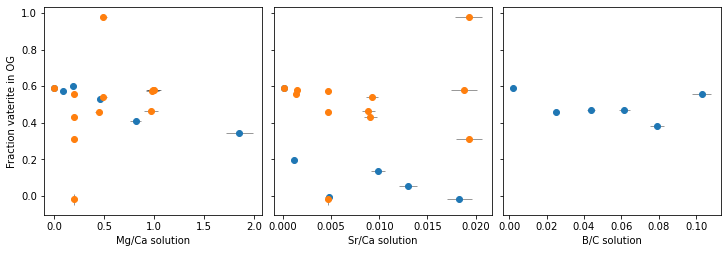

In [30]:
fig, axs = plt.subplots(1, 3, figsize=[10, 3.4], constrained_layout=True, sharey=True)

xvar = 'solution_start'

exp = 'Mg'
var = 'Mg/Ca'
ind = (
    (dat.metadata.Experiment == exp).values &
    (dat.solution_start[var] < 3).values | # exclude high-Mg
    (dat.metadata.Experiment == 'Control').values  # include control data point
)
ax = axs[0]
escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'Fraction vaterite in OG')

exp = 'Mg+Sr'
ind = (
    (dat.metadata.Experiment == exp).values |
    (dat.metadata.Experiment == 'Control').values  # include control data point
)
escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)

exp = 'Sr'
var='Sr/Ca'
ind = (
    (dat.metadata.Experiment == exp).values | 
    (dat.metadata.Experiment == 'Control').values  # include control data point
)
# ind = ind & (dat)
ax=axs[1]
escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)
ax.set_xlabel(f'{var} solution')

exp = 'Mg+Sr'
ind = (
    (dat.metadata.Experiment == exp).values | 
    (dat.metadata.Experiment == 'Control').values  # include control data point
)
escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)

exp = 'B'
var='B/C'
ind = (
    (dat.metadata.Experiment == exp).values |    
    (dat.metadata.Experiment == 'Control').values  # include control data point
)
ax=axs[2]
escatter(dat.loc[ind, (xvar, var)], dat.loc[ind, ('overgrowth', 'F_V')], ax=ax)
ax.set_xlabel(f'{var} solution')

/tmp/ipykernel_907173/338160690.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax, ma = escatter(dat.loc[ind, ('solution_start', 'Mg/Ca')], dat.loc[ind, ('solution_start', 'Sr/Ca')], c=noms(dat.loc[ind, ('overgrowth', 'F_V')].values.flatten()), ax=ax, vmin=0.2, vmax=0.65)


Text(0, 0.5, 'Sr/Ca')

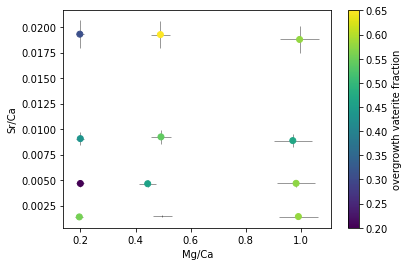

In [34]:
fig, ax = plt.subplots(1,1)

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values

ax, ma = escatter(dat.loc[ind, ('solution_start', 'Mg/Ca')], dat.loc[ind, ('solution_start', 'Sr/Ca')], c=noms(dat.loc[ind, ('overgrowth', 'F_V')].values.flatten()), ax=ax, vmin=0.2, vmax=0.65)
fig.colorbar(ma, ax=ax, label='overgrowth vaterite fraction')

ax.set_xlabel('Mg/Ca')
ax.set_ylabel('Sr/Ca')

### 4. Estimate the composition of the vaterite from inorganic partition coefficients

$$
\begin{align}
D_{OG} &= D_C (1 - F_{V,OG})  + D_V F_{V,OG} \\
D_V &= \frac{D_{OG} - D_C (1 - F_{V,OG})}{F_{V,OG}}
\end{align}
$$

$$
D = \frac{X/Ca_{solid}}{X/Ca_{fluid}}
$$

In [250]:
# All *very* approximate
D_calcite = {
    'Mg': un.ufloat(0.014, 0.03),  # Mg/Ca from Mucci & Morse (1983) via Hasiuk 2010 (10.1016/j.gca.2010.07.030)
    'Sr': un.ufloat(7e-2, 3e-2),  # Sr/Ca from Morse & Bender (1990)
    'Na': un.ufloat(1e-4, 0.5e-4),  # Na/Ca from Kawabata et al (2021; 10.1016/j.chemgeo.2020.119904)
    'B': un.ufloat(1e-3, 0.5e-3),  # BT/DIC, Uchikawa et al (2015)
}

for el, D_cal in D_calcite.items():
    
    dat[('vaterite', f'D_{el}', 'calc', None)] = (dat[('overgrowth', f'D_{el}')].values - (1 - dat[('overgrowth', 'F_V')].values) * D_cal) / dat[('overgrowth', 'F_V')].values

    if el != 'B':
        dat[('calcite', f'{el}/Ca', 'calc', None)] = dat[('solution_start', f'{el}/Ca')].values * D_cal
        dat[('vaterite', f'{el}/Ca', 'calc', 'mol/mol')] = dat[('vaterite', f'D_{el}')].values * dat[('solution_start', f'{el}/Ca')].values
    else:
        dat[('vaterite', f'{el}/C', 'calc', 'mol/mol')] = dat[('vaterite', f'D_{el}')].values * dat[('solution_start', f'{el}/C')].values
        dat[('calcite', f'{el}/C', 'calc', None)] = dat[('solution_start', f'{el}/C')].values * D_cal

/tmp/ipykernel_897855/184410668.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('vaterite', f'D_{el}', 'calc', None)] = (dat[('overgrowth', f'D_{el}')].values - (1 - dat[('overgrowth', 'F_V')].values) * D_cal) / dat[('overgrowth', 'F_V')].values
/tmp/ipykernel_897855/184410668.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('calcite', f'{el}/Ca', 'calc', None)] = dat[('solution_start', f'{el}/Ca')].values * D_cal
/tmp/ipykernel_897855/184410668.py:15: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('vaterite', f'{el}/Ca', 'calc', 'mol/mol')] = dat[('vaterite', f'D_{el}')].values * dat[('solution_start', f'{el}/Ca')].values
/tmp/ipykernel_897855/184410668.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  dat[('vaterite', f'D_{el}', 'calc', None)] = (dat[('overgrowth', f'D_{el}')].values - (1 - dat[('overgrowth', 'F_V')].values) * D_cal) / dat[('overgr

In [251]:
dat.sort_index(axis=1, inplace=True)

In [252]:
dat.to_csv('Data/vaterite_processed.csv')
dat.to_pickle('Data/vaterite_processed.pkl')

## TODO

- Clean up the plots below to make a good story
- Think about calcite partitioning coefficients

## Look at some patterns!

In [253]:
ind = (dat.metadata.Experiment == 'Sr').values
dat.loc[ind, 'overgrowth']

Quantity,B/Ca,D_B,D_Mg,D_Na,D_Sr,F_V,Mg/Ca,Na/Ca,Sr/Ca
Instrument,calc,calc,calc,calc,calc,calc,calc,calc,calc
Unit,mol/mol,None,None,None,None,fractional_abundance,mol/mol,mol/mol,mol/mol
22,nan+/-nan,nan+/-nan,-0.076+/-0.011,2.48+/-0.24,0.089+/-0.011,0.197+/-0.013,(-3.5+/-0.4)e-05,0.065+/-0.004,0.000102+/-0.000011
23,nan+/-nan,nan+/-nan,0.137+/-0.011,0.08+/-0.04,0.094+/-0.009,-0.008+/-0.014,-0.000101+/-0.000004,0.0022+/-0.0012,0.000448+/-0.000027
24,nan+/-nan,nan+/-nan,0.178+/-0.015,0.08+/-0.05,0.094+/-0.008,0.138+/-0.012,-0.000109+/-0.000005,0.0020+/-0.0012,0.00093+/-0.00005
25,nan+/-nan,nan+/-nan,0.150+/-0.013,0.53+/-0.08,0.101+/-0.009,0.053+/-0.015,(-8.6+/-0.4)e-05,0.0136+/-0.0018,0.00132+/-0.00007
26,nan+/-nan,nan+/-nan,0.102+/-0.008,0.16+/-0.05,0.097+/-0.009,-0.016+/-0.014,-0.000105+/-0.000004,0.0044+/-0.0012,0.00177+/-0.00010


Text(0, 0.5, 'B/C vaterite')

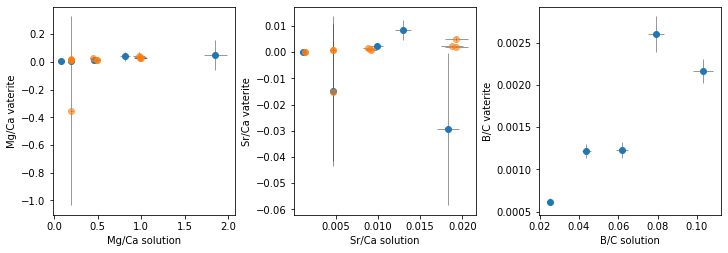

In [254]:
fig, axs = plt.subplots(1, 3, figsize=[10, 3.4], constrained_layout=True)

xvar = 'solution_start'

exp = 'Mg'
var = 'Mg/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start[var] < 3).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
# ind = ind & (dat.overgrowth.F_v.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax, alpha=0.6)

exp = 'Sr'
var='Sr/Ca'
ind = (dat.metadata.Experiment == exp).values
# ind = ind & (dat.overgrowth.F_v.values > 0)
ax=axs[1]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
# ind = ind & (dat.overgrowth.F_v.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax, alpha=0.6)


exp = 'B'
var='B/C'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')


Outliers where F_v < 0, (no new vaterite grew) remove them

/tmp/ipykernel_897855/582088200.py:16: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/582088200.py:22: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/582088200.py:30: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


Text(0, 0.5, 'B/C vaterite')

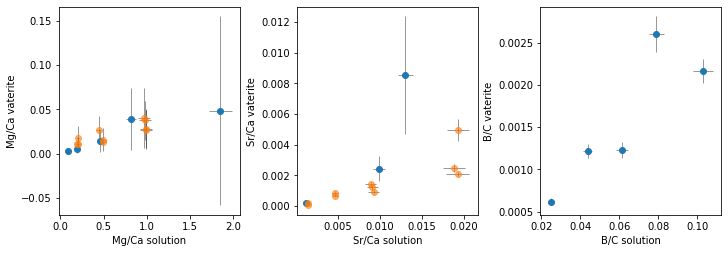

In [266]:
fig, axs = plt.subplots(1, 3, figsize=[10, 3.4], constrained_layout=True)

xvar = 'solution_start'

exp = 'Mg'
var = 'Mg/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start[var] < 3).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax, alpha=0.6)

exp = 'Sr'
var='Sr/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
ax=axs[1]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax, alpha=0.6)


exp = 'B'
var='B/C'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')


/tmp/ipykernel_897855/2586051364.py:17: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/2586051364.py:23: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/2586051364.py:31: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


Text(0, 0.5, 'Na/Ca overgrowth')

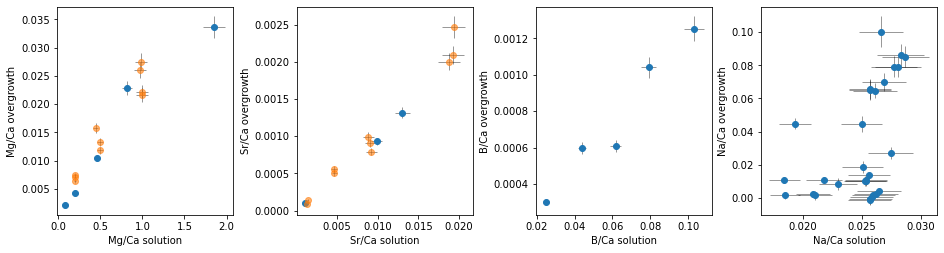

In [256]:
fig, axs = plt.subplots(1, 4, figsize=[13, 3.4], constrained_layout=True)

xvar = 'solution_start'
phase = 'overgrowth'

exp = 'Mg'
var = 'Mg/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start[var] < 3).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, (phase, var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} {phase}')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, (phase, var)].values[:,0], ax=ax, alpha=0.6)

exp = 'Sr'
var='Sr/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
ax=axs[1]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, (phase, var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} {phase}')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, (phase, var)].values[:,0], ax=ax, alpha=0.6)


exp = 'B'
var='B/Ca'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, (xvar, 'B/C')].values[:,0], dat.loc[ind, (phase, var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} {phase}')

var='Na/Ca'
ax=axs[3]
escatter(dat.loc[:, (xvar, var)].values[:,0], dat.loc[:, (phase, var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} {phase}')


/tmp/ipykernel_897855/693931938.py:17: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/693931938.py:24: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/693931938.py:33: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


(0.0, 0.012)

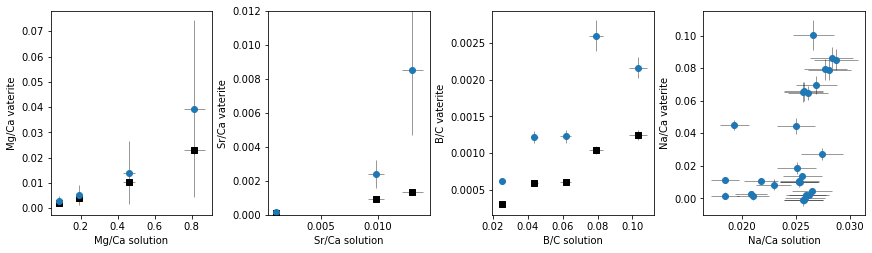

In [257]:
fig, axs = plt.subplots(1, 4, figsize=[12, 3.4], constrained_layout=True)

xvar = 'solution_start'

exp = 'Mg'
var = 'Mg/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start[var] < 1.5).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', var)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax, alpha=0.6)
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', var)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)

exp = 'Sr'
var='Sr/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
ax=axs[1]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', var)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax, alpha=0.6)
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', var)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)

exp = 'B'
var='B/C'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', 'B/Ca')].values[:,0], ax=ax, marker='s', color='k', zorder=-1)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

var='Na/Ca'
ax=axs[3]
escatter(dat.loc[:, (xvar, var)].values[:,0], dat.loc[:, (phase, var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

axs[1].set_ylim(0, 0.012)

In [283]:
dat.loc[((dat.vaterite['Na/Ca'] < 0.2) & (dat.solution_start['Na/Ca'] > 0.024)).values, :]

Type                  calcite                                      \
Quantity                  B/C              Mg/Ca            Na/Ca   
Instrument               calc               calc             calc   
Unit                      NaN                NaN              NaN   
23                (8+/-4)e-06   (-1.0+/-2.2)e-05  (2.6+/-1.3)e-06   
24            (2.9+/-1.4)e-06   (-0.9+/-1.8)e-05  (2.6+/-1.3)e-06   
26            (6.3+/-3.2)e-06   (-1.4+/-3.1)e-05  (2.6+/-1.3)e-06   
30            (1.3+/-0.7)e-07      0.003+/-0.006  (2.7+/-1.3)e-06   
31                (7+/-4)e-06      0.003+/-0.006  (2.7+/-1.4)e-06   
32            (1.0+/-0.5)e-05      0.014+/-0.029  (2.6+/-1.3)e-06   
33           (-4.1+/-2.1)e-07      0.014+/-0.029  (2.6+/-1.3)e-06   
35            (6.8+/-3.4)e-07      0.003+/-0.006  (2.5+/-1.3)e-06   
36            (1.0+/-0.5)e-05      0.003+/-0.006  (2.5+/-1.3)e-06   
37            (1.9+/-0.9)e-06      0.014+/-0.030  (2.6+/-1.3)e-06   
38                (8+/-4)e-06      0.014+/-0.030  (2.6+/-1.3)e-06   
41                (8+/-4)e-06      0.007+/-0.015  (2.5+/-1.3)e-06   
42            (6.2+/-3.1)e-06      0.007+/-0.015  (2.5+/-1.3)e-06   
43            (2.5+/-1.3)e-05    (0.8+/-1.6)e-05  (2.8+/-1.4)e-06   
44            (4.4+/-2.2)e-05   (-1.5+/-3.2)e-06  (2.9+/-1.4)e-06   
45            (6.2+/-3.1)e-05  0.00005+/-0.00010  (2.7+/-1.4)e-06   
47          0.00010+/-0.00005   (-1.0+/-2.1)e-05  (2.8+/-1.4)e-06   

Type                                         derived metadata             \
Quantity                  Sr/Ca                    f    Batch Experiment   
Instrument                 calc                 calc       NA         NA   
Unit                        NaN fractional_abundance       NA         NA   
23            0.00033+/-0.00005        0.433+/-0.006        2         Sr   
24            0.00069+/-0.00011        0.415+/-0.006        2         Sr   
26            0.00128+/-0.00020        0.440+/-0.006        2         Sr   
30            0.00033+/-0.00005        0.210+/-0.007        3      Mg+Sr   
31            0.00063+/-0.00010        0.341+/-0.007        3      Mg+Sr   
32            0.00033+/-0.00005        0.263+/-0.007        3      Mg+Sr   
33            0.00062+/-0.00010        0.282+/-0.007        3      Mg+Sr   
35              (9.8+/-1.6)e-05        0.284+/-0.007        3      Mg+Sr   
36            0.00135+/-0.00022        0.281+/-0.007        3      Mg+Sr   
37          0.000100+/-0.000016        0.300+/-0.007        3      Mg+Sr   
38            0.00131+/-0.00021        0.290+/-0.007        3      Mg+Sr   
41            0.00065+/-0.00010        0.345+/-0.007        3      Mg+Sr   
42            0.00135+/-0.00021        0.310+/-0.007        3      Mg+Sr   
43              (7.3+/-1.2)e-06        0.306+/-0.007        4          B   
44              (6.9+/-1.1)e-06        0.315+/-0.007        4          B   
45              (7.6+/-1.2)e-06        0.317+/-0.007        4          B   
47              (6.0+/-1.0)e-06        0.321+/-0.007        4          B   

Type                 overgrowth                                     ...  \
Quantity                   B/Ca              D_B              D_Mg  ...   
Instrument                 calc             calc              calc  ...   
Unit                    mol/mol              NaN               NaN  ...   
23                    nan+/-nan        nan+/-nan     0.137+/-0.011  ...   
24                    nan+/-nan        nan+/-nan     0.178+/-0.015  ...   
26                    nan+/-nan        nan+/-nan     0.102+/-0.008  ...   
30                    nan+/-nan        nan+/-nan     0.047+/-0.004  ...   
31                    nan+/-nan        nan+/-nan   0.0317+/-0.0028  ...   
32                    nan+/-nan        nan+/-nan   0.0280+/-0.0025  ...   
33                    nan+/-nan        nan+/-nan   0.0268+/-0.0024  ...   
35                    nan+/-nan        nan+/-nan   0.0364+/-0.0033  ...   
36                    nan+/-nan        nan+/-nan   0.

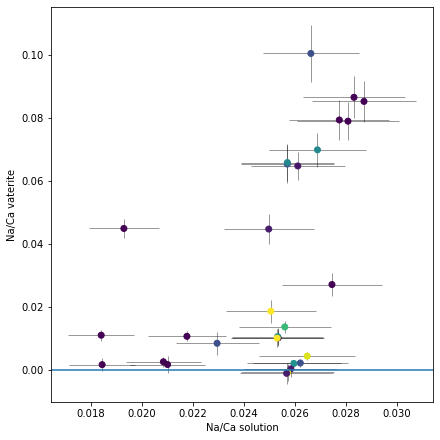

In [297]:
fig, ax = plt.subplots(1, 1, figsize=[6,6], constrained_layout=True)

var='Na/Ca'
escatter(dat.loc[:, (xvar, var)].values[:,0], dat.loc[:, (phase, var)].values[:,0], ax=ax, c=noms(dat.loc[:, ('solution_start', 'Sr/Ca')].values[:,0]))
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{var} vaterite')

ax.axhline(0)

<AxesSubplot:>

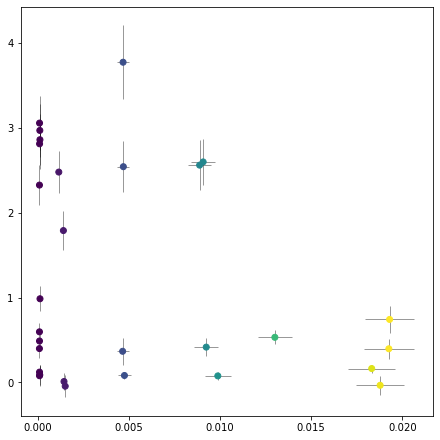

In [303]:
fig, ax = plt.subplots(1, 1, figsize=[6,6], constrained_layout=True)
escatter(dat.loc[:, ('solution_start', 'Sr/Ca')].values[:,0], dat.loc[:, ('overgrowth', 'D_Na')].values[:,0], ax=ax, c=noms(dat.loc[:, ('solution_start', 'Sr/Ca')].values[:,0]))
# ax.set_ylim(-30, 100)

/tmp/ipykernel_897855/160313399.py:4: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


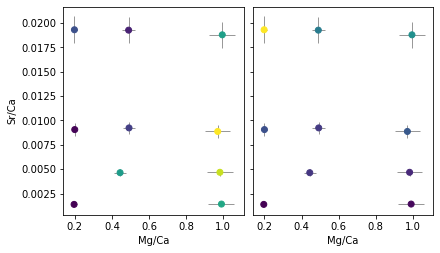

In [258]:
fig, axs = plt.subplots(1, 2, figsize=[6, 3.4], constrained_layout=True, sharey=True)
exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)

escatter(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0], dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0], c=noms(dat.loc[ind, ('vaterite', 'Mg/Ca')].values[:,0]), ax=axs[0])


escatter(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0], dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0], c=noms(dat.loc[ind, ('vaterite', 'Sr/Ca')].values[:,0]), ax=axs[1])


axs[0].set_ylabel('Sr/Ca')
for ax in axs:
    ax.set_xlabel('Mg/Ca')

/tmp/ipykernel_897855/458832456.py:4: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/458832456.py:11: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/458832456.py:16: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


Text(0, 0.5, 'Vaterite $D_{Mg}$')

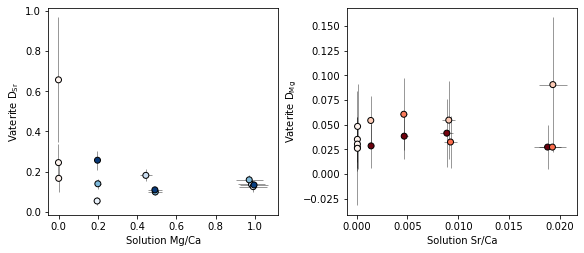

In [259]:
fig, axs = plt.subplots(1, 2, figsize=[8, 3.4], constrained_layout=True, sharey=False)
exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values  # | (dat.metadata.Experiment == 'Control').values
ind = ind & (dat.overgrowth.F_V.values > 0)

escatter(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0], dat.loc[ind, ('vaterite', 'D_Sr')].values[:,0], ax=axs[0], c=noms(dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0]), cmap=plt.cm.Blues, edgecolor='k', lw=1, vmin=0, vmax=0.02)
escatter(dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0], dat.loc[ind, ('vaterite', 'D_Mg')].values[:,0], ax=axs[1], c=noms(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0]), cmap=plt.cm.Reds, edgecolor='k', lw=1, vmin=0, vmax=1)

exp = 'Sr'
ind = (dat.metadata.Experiment == exp).values  # | (dat.metadata.Experiment == 'Control').values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0], dat.loc[ind, ('vaterite', 'D_Sr')].values[:,0], ax=axs[0], c=noms(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0]), cmap=plt.cm.Reds, edgecolor='k', lw=1, vmin=0, vmax=1)

exp = 'Mg'
ind = (dat.metadata.Experiment == exp).values  # | (dat.metadata.Experiment == 'Control').values
ind = ind & (dat.overgrowth.F_V.values > 0)
ind = ind & (dat.index.values.reshape(-1,1) != 21)  # remove aragonite experiment
escatter(dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0], dat.loc[ind, ('vaterite', 'D_Mg')].values[:,0], ax=axs[1], c=noms(dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0]), cmap=plt.cm.Reds, edgecolor='k', lw=1, vmin=0, vmax=0.02)


axs[0].set_xlabel('Solution Mg/Ca')
axs[0].set_ylabel('Vaterite $D_{Sr}$')

axs[1].set_xlabel('Solution Sr/Ca')
axs[1].set_ylabel('Vaterite $D_{Mg}$')

# for ax in axs:
#     ax.set_ylim(0, ax.get_ylim()[1])
#     ax.set_xlim(0, ax.get_xlim()[1])

In [260]:
exp = 'Mg'
ind = (dat.metadata.Experiment == exp).values  # | (dat.metadata.Experiment == 'Control').values
ind = ind & (dat.overgrowth.F_V.values > 0)

/tmp/ipykernel_897855/972254643.py:3: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


In [268]:
exp = 'Sr'
ind = (dat.metadata.Experiment == exp).values  # | (dat.metadata.Experiment == 'Control').values
# ind = ind & (dat.overgrowth.F_V.values > 0)
dat.loc[ind,'vaterite']

Quantity,B/C,D_B,D_Mg,D_Na,D_Sr,Mg/Ca,Na/Ca,Sr/Ca
Instrument,calc,calc,calc,calc,calc,calc,calc,calc
Unit,mol/mol,None,None,None,None,mol/mol,mol/mol,mol/mol
22,nan+/-nan,nan+/-nan,-0.44+/-0.14,12.5+/-1.6,0.17+/-0.07,-0.00020+/-0.00006,0.328+/-0.034,0.00019+/-0.00008
23,nan+/-nan,nan+/-nan,-16+/-30,-11+/-22,-3+/-6,0.012+/-0.022,-0.3+/-0.6,-0.015+/-0.029
24,nan+/-nan,nan+/-nan,1.20+/-0.25,0.56+/-0.34,0.25+/-0.09,-0.00074+/-0.00014,0.015+/-0.009,0.0024+/-0.0008
25,nan+/-nan,nan+/-nan,2.6+/-1.0,10.0+/-3.2,0.66+/-0.31,-0.0015+/-0.0005,0.26+/-0.08,0.009+/-0.004
26,nan+/-nan,nan+/-nan,-6+/-5,-10+/-10,-1.6+/-1.6,0.006+/-0.005,-0.27+/-0.26,-0.029+/-0.029


/tmp/ipykernel_897855/2684662537.py:18: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/2684662537.py:25: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/2684662537.py:34: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


Text(0, 0.5, 'Na/Ca vaterite')

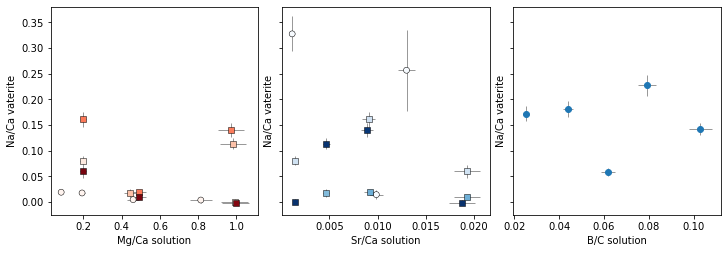

In [262]:
fig, axs = plt.subplots(1, 3, figsize=[10, 3.4], constrained_layout=True, sharey=True)

xvar = 'solution_start'
yvar='Na/Ca'

exp = 'Mg'
var = 'Mg/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start[var] < 1.5).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', yvar)].values[:,0], ax=ax, c=noms(dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0]), vmin=0, vmax=0.02, cmap=plt.cm.Reds, lw=0.5, edgecolor='k')
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', yvar)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{yvar} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', yvar)].values[:,0], ax=ax, marker='s', c=noms(dat.loc[ind, ('solution_start', 'Sr/Ca')].values[:,0]), vmin=0, vmax=0.02, cmap=plt.cm.Reds, lw=0.5, edgecolor='k')
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', yvar)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)

exp = 'Sr'
var='Sr/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
ax=axs[1]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', yvar)].values[:,0], ax=ax, c=noms(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0]), vmin=0, vmax=1, cmap=plt.cm.Blues, lw=0.5, edgecolor='k')
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', yvar)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{yvar} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', yvar)].values[:,0], ax=ax, marker='s', c=noms(dat.loc[ind, ('solution_start', 'Mg/Ca')].values[:,0]), vmin=0, vmax=1, cmap=plt.cm.Blues, lw=0.5, edgecolor='k')
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', yvar)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)

exp = 'B'
var='B/C'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('vaterite', yvar)].values[:,0], ax=ax)
# escatter(dat.loc[ind, (xvar, var)].values[:,0], dat.loc[ind, ('overgrowth', yvar)].values[:,0], ax=ax, marker='s', color='k', zorder=-1)
ax.set_xlabel(f'{var} solution')
ax.set_ylabel(f'{yvar} vaterite')

# axs[1].set_ylim(0, 0.004)

/tmp/ipykernel_897855/2063065230.py:16: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/2063065230.py:22: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/2063065230.py:30: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


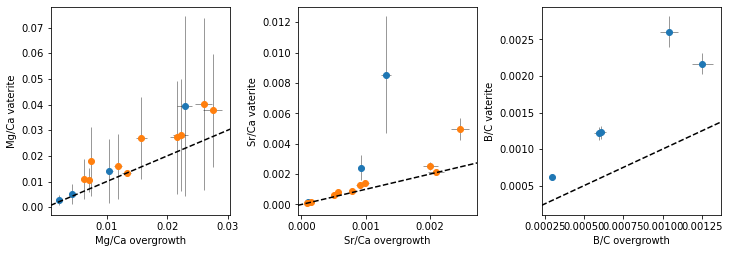

In [263]:
fig, axs = plt.subplots(1, 3, figsize=[10, 3.4], constrained_layout=True)

xvar = 'solution_start'

exp = 'Mg'
var = 'Mg/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start[var] < 1.5).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} overgrowth')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)

exp = 'Sr'
var='Sr/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
ax=axs[1]
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} overgrowth')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)

exp = 'B'
var='B/C'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, ('overgrowth', 'B/Ca')].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} overgrowth')
ax.set_ylabel(f'{var} vaterite')

for ax in axs:
    ax.set_xlim(ax.get_xlim())
    ax.plot(ax.get_xlim(), ax.get_xlim(), ls='--', c='k')


/tmp/ipykernel_897855/945152471.py:16: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/945152471.py:22: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/945152471.py:30: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


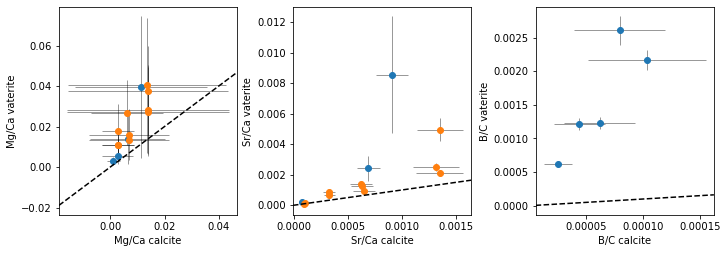

In [264]:
fig, axs = plt.subplots(1, 3, figsize=[10, 3.4], constrained_layout=True)

xvar = 'solution_start'

exp = 'Mg'
var = 'Mg/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start[var] < 1.5).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, ('calcite', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} calcite')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, ('calcite', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)

exp = 'Sr'
var='Sr/Ca'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
ax=axs[1]
escatter(dat.loc[ind, ('calcite', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} calcite')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, ('calcite', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)

exp = 'B'
var='B/C'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, ('calcite', 'B/C')].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} calcite')
ax.set_ylabel(f'{var} vaterite')

for ax in axs:
    ax.set_xlim(ax.get_xlim())
    ax.plot(ax.get_xlim(), ax.get_xlim(), ls='--', c='k')

/tmp/ipykernel_897855/202181858.py:16: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/202181858.py:22: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)
/tmp/ipykernel_897855/202181858.py:30: RuntimeWarning: invalid value encountered in greater
  ind = ind & (dat.overgrowth.F_V.values > 0)


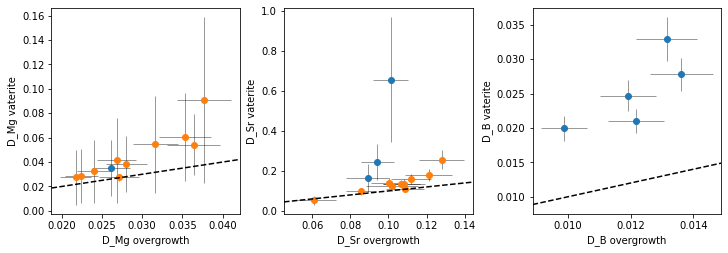

In [265]:
fig, axs = plt.subplots(1, 3, figsize=[10, 3.4], constrained_layout=True)

xvar = 'solution_start'

exp = 'Mg'
var = 'D_Mg'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.solution_start['Mg'] < 1.5).values  # exclude high-Mg
ax = axs[0]
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} overgrowth')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)

exp = 'Sr'
var='D_Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
ax=axs[1]
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} overgrowth')
ax.set_ylabel(f'{var} vaterite')

exp = 'Mg+Sr'
ind = (dat.metadata.Experiment == exp).values
ind = ind & (dat.overgrowth.F_V.values > 0)
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)

exp = 'B'
var='D_B'
ind = (dat.metadata.Experiment == exp).values
ax=axs[2]
escatter(dat.loc[ind, ('overgrowth', var)].values[:,0], dat.loc[ind, ('vaterite', var)].values[:,0], ax=ax)
ax.set_xlabel(f'{var} overgrowth')
ax.set_ylabel(f'{var} vaterite')

for ax in axs:
    ax.set_xlim(ax.get_xlim())
    ax.plot(ax.get_xlim(), ax.get_xlim(), ls='--', c='k')
